In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
DATASET_PATH = "./dataset/" 
ORIG_DIR = os.path.join(DATASET_PATH, 'originalData')
MASK_DIR = os.path.join(DATASET_PATH, 'annotatedData')

orig_files = sorted([f for f in os.listdir(ORIG_DIR) if not f.startswith('.')])

thermal_sequence_list = []
mask_sequence_list = []

In [3]:
for filename in orig_files:
    orig_path = os.path.join(ORIG_DIR, filename)
    mask_path = os.path.join(MASK_DIR, filename)
    
    orig_img = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    thermal_sequence_list.append(orig_img)
    if mask_img is not None:
        _, binary_mask = cv2.threshold(mask_img, 1, 255, cv2.THRESH_BINARY)
        mask_sequence_list.append(binary_mask / 255.0) 

In [4]:
thermal_volume = np.stack(thermal_sequence_list, axis=0).astype(np.float32)
mask_volume = np.stack(mask_sequence_list, axis=0).astype(np.float32)

vol_min = thermal_volume.min()
vol_max = thermal_volume.max()
thermal_volume_norm = (thermal_volume - vol_min) / (vol_max - vol_min)

In [5]:
T, H, W = thermal_volume_norm.shape

# Flatten spatial dimensions: Shape becomes (T, H*W) then transpose to (H*W, T)
thermal_vectors = thermal_volume_norm.reshape(T, -1).T
mask_vectors = mask_volume.reshape(T, -1).T

# Find purely healthy pixels (sum of mask across all time steps is 0)
healthy_indices = np.where(np.sum(mask_vectors, axis=1) == 0)[0]
healthy_data = thermal_vectors[healthy_indices]

In [6]:
class TemporalDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32)

train_dataset = TemporalDataset(healthy_data)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True) 

In [7]:
class DeepSVDD_MLP(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super(DeepSVDD_MLP, self).__init__()
        
        # CRITICAL: bias=False prevents trivial network collapse in Deep SVDD
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128, bias=False),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64, bias=False),
            nn.LeakyReLU(0.2),
            nn.Linear(64, latent_dim, bias=False)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


Using device: cpu


In [9]:
model = DeepSVDD_MLP(input_dim=T, latent_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [10]:
def initialize_center(model, dataloader, device):
    """Passes initial healthy data through to find the fixed hypersphere center."""
    print("Initializing hypersphere center...")
    model.eval()
    z_sum = 0
    n_samples = 0
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            z = model(batch)
            z_sum += torch.sum(z, dim=0)
            n_samples += z.shape[0]
    return (z_sum / n_samples).to(device)

center_c = initialize_center(model, train_loader, device)

Initializing hypersphere center...


In [11]:
EPOCHS = 15
epoch_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for batch in train_loader:
        batch = batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch)
        
        # SVDD Loss: Distance squared from the outputs to the fixed center
        distances = torch.sum((outputs - center_c) ** 2, dim=1)
        loss = torch.mean(distances)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Hypersphere Volume Loss: {avg_loss:.6f}")

Epoch [1/15] - Hypersphere Volume Loss: 0.009792
Epoch [2/15] - Hypersphere Volume Loss: 0.000942
Epoch [3/15] - Hypersphere Volume Loss: 0.000890
Epoch [4/15] - Hypersphere Volume Loss: 0.000665
Epoch [5/15] - Hypersphere Volume Loss: 0.000763
Epoch [6/15] - Hypersphere Volume Loss: 0.000633
Epoch [7/15] - Hypersphere Volume Loss: 0.000618
Epoch [8/15] - Hypersphere Volume Loss: 0.000691
Epoch [9/15] - Hypersphere Volume Loss: 0.000571
Epoch [10/15] - Hypersphere Volume Loss: 0.000515
Epoch [11/15] - Hypersphere Volume Loss: 0.000570
Epoch [12/15] - Hypersphere Volume Loss: 0.000553
Epoch [13/15] - Hypersphere Volume Loss: 0.000503
Epoch [14/15] - Hypersphere Volume Loss: 0.000921
Epoch [15/15] - Hypersphere Volume Loss: 0.000487


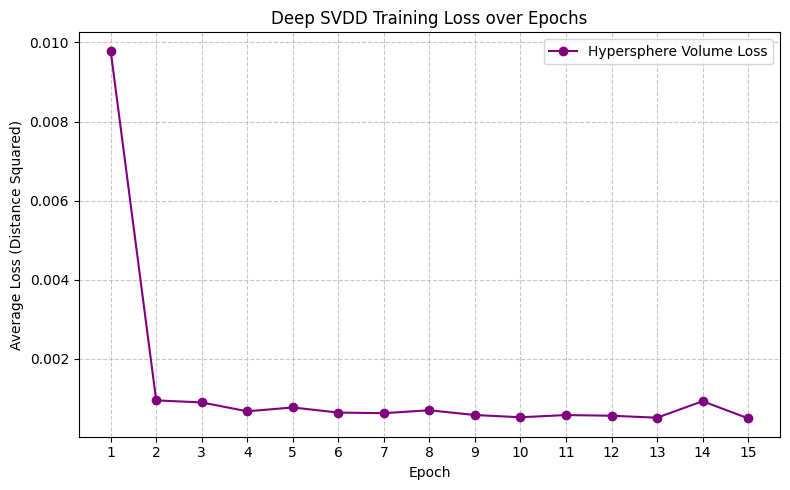

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker='o', linestyle='-', color='purple', label='Hypersphere Volume Loss')
plt.title('Deep SVDD Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Loss (Distance Squared)')
plt.xticks(range(1, EPOCHS + 1)) # Ensure x-axis shows whole numbers for epochs
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
model.eval()

all_vectors_dataset = TemporalDataset(thermal_vectors)
inference_loader = DataLoader(all_vectors_dataset, batch_size=1024, shuffle=False)

anomaly_scores = []

with torch.no_grad():
    for batch in inference_loader:
        batch = batch.to(device)
        outputs = model(batch)
        # Calculate Euclidean distance from the center for every pixel
        distances = torch.sqrt(torch.sum((outputs - center_c) ** 2, dim=1))
        anomaly_scores.append(distances.cpu().numpy())

anomaly_scores = np.concatenate(anomaly_scores)
anomaly_map = anomaly_scores.reshape(H, W)

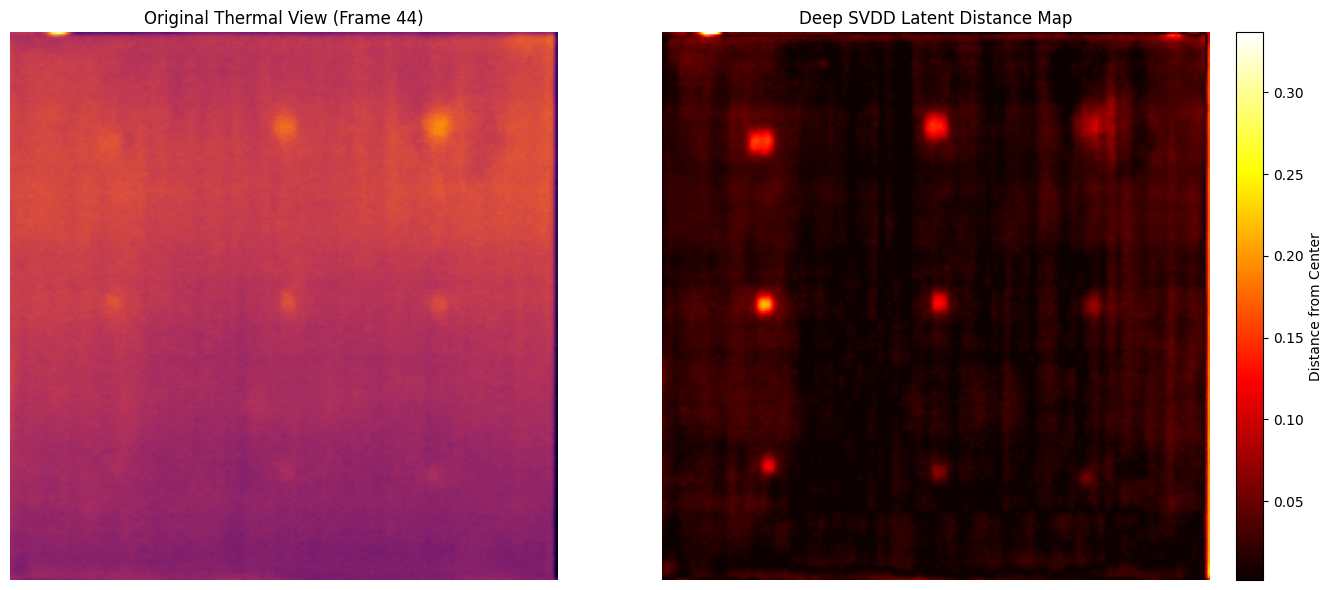

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mid_frame = 44
axes[0].imshow(thermal_volume[mid_frame, :, :], cmap='inferno')
axes[0].set_title(f"Original Thermal View (Frame {mid_frame})")
axes[0].axis('off')

im = axes[1].imshow(anomaly_map, cmap='hot')
axes[1].set_title("Deep SVDD Latent Distance Map")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Distance from Center")

plt.tight_layout()
plt.show()